In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL3Nrb2pha3UtYWRtaW4vRG9jdW1lbnRzL3Byb2plY3RzL2FwcGxpZWQtc29mdC1jb21wL2RvY3MvbGVjdHVyZS1ub3RlL20wNy1yZXByZXNlbnRhdGlvbg=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/importlib/_bootstrap.py": 1756893439.1114566, "/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/importlib/_bootstrap_external.py": 1756893439.111954, "/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/zipimport.py": 1756893439.5981421, "/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/codecs.py": 1756893438.8338757, "/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/encodings/aliases.py": 1756893438.9201, "/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/encodings/__init__.py": 1756893438.9179149, "/Users/skojaku-admin/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/encodings/utf_8.py": 1756893438.9597929, "/Users/skojaku-admin/.local/share/uv/python/cpyt

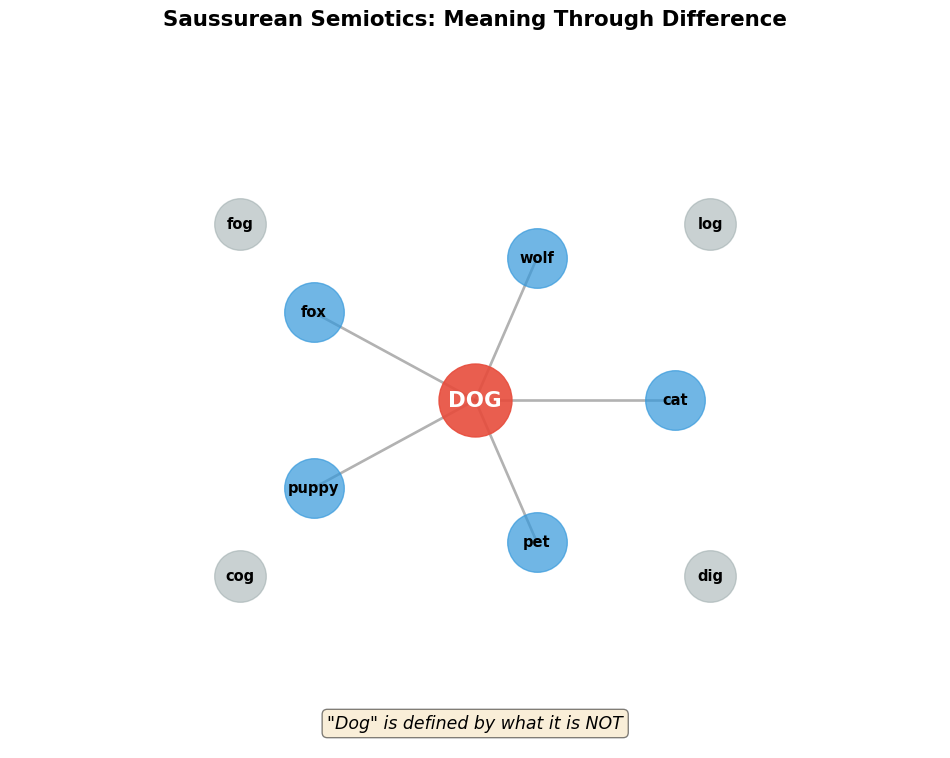

In [2]:
#| fig-cap: The meaning of 'dog' emerges from its position in a network of contrasts, not from an intrinsic essence.
#| label: fig-saussure-system
#| code-fold: true

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

# Create a network showing semantic relationships
G = nx.Graph()

# Add nodes
center_word = "DOG"
related = ["cat", "wolf", "fox", "puppy", "pet"]
contrasts = ["log", "fog", "cog", "dig"]

G.add_node(center_word)
for word in related + contrasts:
    G.add_node(word)

# Add edges for related terms
for word in related:
    G.add_edge(center_word, word)

# Position nodes
pos = {center_word: (0, 0)}

# Related words in a circle around center
angle_step = 2 * np.pi / len(related)
for i, word in enumerate(related):
    angle = i * angle_step
    pos[word] = (1.5 * np.cos(angle), 1.5 * np.sin(angle))

# Contrast words further out
angle_step = 2 * np.pi / len(contrasts)
for i, word in enumerate(contrasts):
    angle = i * angle_step + np.pi/4
    pos[word] = (2.5 * np.cos(angle), 2.5 * np.sin(angle))

# Draw the network
# Center node
nx.draw_networkx_nodes(G, pos, nodelist=[center_word],
                       node_color='#e74c3c', node_size=3000,
                       alpha=0.9, ax=ax)

# Related nodes
nx.draw_networkx_nodes(G, pos, nodelist=related,
                       node_color='#3498db', node_size=2000,
                       alpha=0.7, ax=ax)

# Contrast nodes
nx.draw_networkx_nodes(G, pos, nodelist=contrasts,
                       node_color='#95a5a6', node_size=1500,
                       alpha=0.5, ax=ax)

# Edges
nx.draw_networkx_edges(G, pos, width=2, alpha=0.3, ax=ax)

# Labels
nx.draw_networkx_labels(G, pos,
                        {center_word: center_word},
                        font_size=16, font_weight='bold',
                        font_color='white', ax=ax)

label_pos = {k: (v[0], v[1]) for k, v in pos.items() if k != center_word}
nx.draw_networkx_labels(G, label_pos,
                        {k: k for k in related + contrasts},
                        font_size=11, font_weight='bold', ax=ax)

# Add annotations
ax.text(0, -3.3, '"Dog" is defined by what it is NOT', fontsize=13,
        ha='center', style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.axis('off')
ax.set_title('Saussurean Semiotics: Meaning Through Difference',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

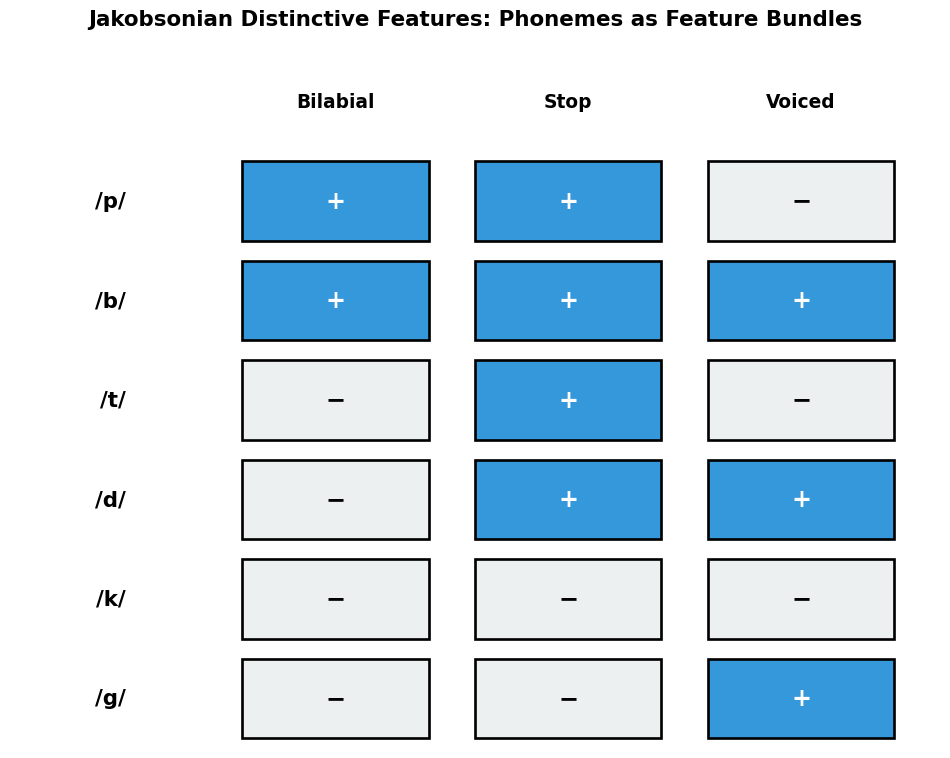

In [3]:
#| fig-cap: Phonemes as vectors in a space of binary features. Position, not essence, determines identity.
#| label: fig-jakobson-features
#| code-fold: true

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define phonemes with binary features
phonemes = {
    'p': [1, 1, 0],  # [bilabial, stop, voiced]
    'b': [1, 1, 1],
    't': [0, 1, 0],  # [dental, stop, voiced]
    'd': [0, 1, 1],
    'k': [0, 0, 0],  # [velar, stop, voiced]
    'g': [0, 0, 1]
}

# Create DataFrame
df = pd.DataFrame.from_dict(phonemes, orient='index',
                            columns=['Bilabial', 'Stop', 'Voiced'])

fig, ax = plt.subplots(figsize=(10, 8))

# Create a heatmap-style visualization
for i, (phoneme, features) in enumerate(phonemes.items()):
    y = 5 - i
    for j, (feature, value) in enumerate(zip(['Bilabial', 'Stop', 'Voiced'], features)):
        color = '#3498db' if value == 1 else '#ecf0f1'
        rect = plt.Rectangle((j, y - 0.4), 0.8, 0.8, facecolor=color,
                            edgecolor='black', linewidth=2)
        ax.add_patch(rect)

        # Add value text
        text_color = 'white' if value == 1 else 'black'
        ax.text(j + 0.4, y, '+' if value == 1 else '−',
               ha='center', va='center', fontsize=18,
               fontweight='bold', color=text_color)

    # Add phoneme label
    ax.text(-0.5, y, f'/{phoneme}/',
           ha='right', va='center', fontsize=16, fontweight='bold')

# Add feature labels
feature_labels = ['Bilabial', 'Stop', 'Voiced']
for j, label in enumerate(feature_labels):
    ax.text(j + 0.4, 6, label, ha='center', va='center',
           fontsize=14, fontweight='bold', rotation=0)

ax.set_xlim(-1, 3)
ax.set_ylim(-0.5, 6.5)
ax.axis('off')
ax.set_title('Jakobsonian Distinctive Features: Phonemes as Feature Bundles',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

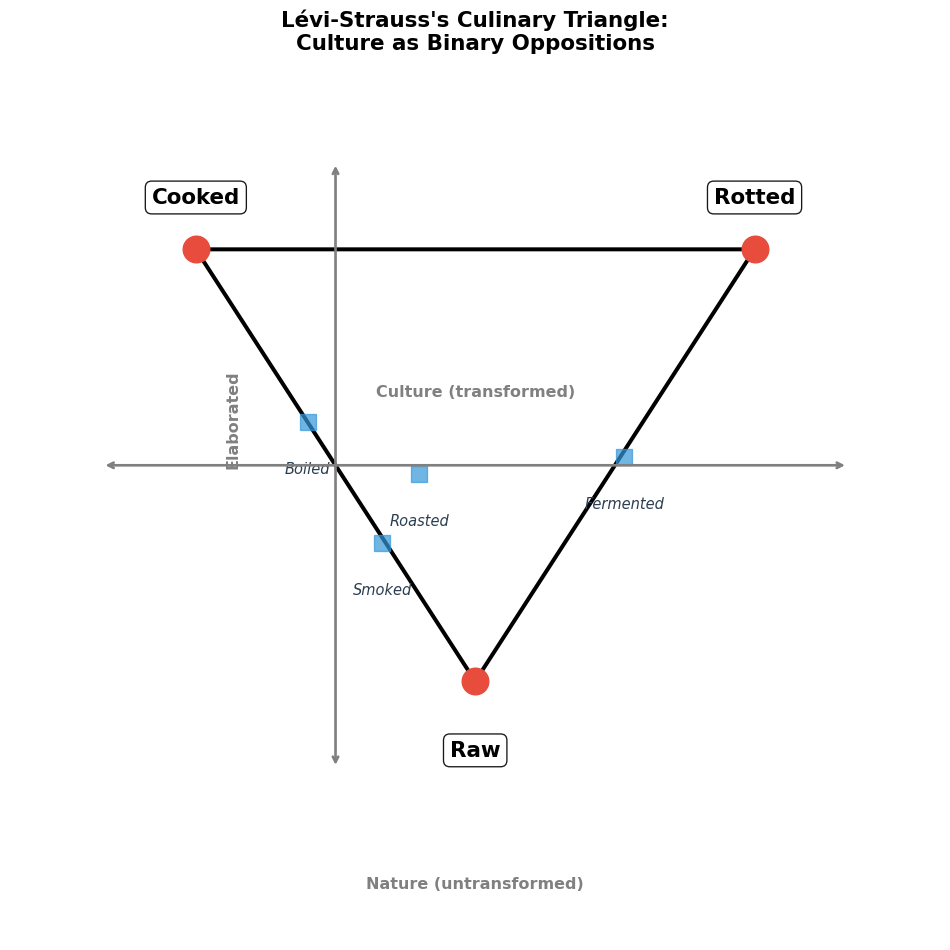

In [4]:
#| fig-cap: Lévi-Strauss's culinary triangle maps food preparation methods through binary oppositions.
#| label: fig-culinary-triangle
#| code-fold: true

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 10))

# Define triangle vertices
raw = (0, 0)
cooked = (-1.5, 2.5)
rotted = (1.5, 2.5)

# Draw triangle
triangle = plt.Polygon([raw, cooked, rotted], fill=False,
                       edgecolor='black', linewidth=3)
ax.add_patch(triangle)

# Add points
points = {'Raw': raw, 'Cooked': cooked, 'Rotted': rotted}
for label, (x, y) in points.items():
    ax.plot(x, y, 'o', markersize=20, color='#e74c3c', zorder=3)
    offset = (0, -0.4) if label == 'Raw' else (0, 0.3)
    ax.text(x + offset[0], y + offset[1], label,
           fontsize=16, fontweight='bold', ha='center', va='center',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Add intermediate categories
intermediates = {
    'Smoked': (-0.5, 0.8),
    'Boiled': (-0.9, 1.5),
    'Roasted': (-0.3, 1.2),
    'Fermented': (0.8, 1.3)
}

for label, (x, y) in intermediates.items():
    ax.plot(x, y, 's', markersize=12, color='#3498db', alpha=0.7, zorder=2)
    ax.text(x, y - 0.3, label, fontsize=11, ha='center',
           style='italic', color='#2c3e50')

# Add axes labels
ax.annotate('', xy=(-2, 1.25), xytext=(2, 1.25),
           arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
ax.text(0, 1.65, 'Culture (transformed)', ha='center',
       fontsize=12, fontweight='bold', color='gray')

ax.annotate('', xy=(-0.75, -0.5), xytext=(-0.75, 3),
           arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
ax.text(-1.3, 1.25, 'Elaborated', ha='center', fontsize=12,
       fontweight='bold', color='gray', rotation=90)

ax.text(0, -1.2, 'Nature (untransformed)', ha='center',
       fontsize=12, fontweight='bold', color='gray')

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.5, 3.5)
ax.axis('off')
ax.set_title("Lévi-Strauss's Culinary Triangle:\nCulture as Binary Oppositions",
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

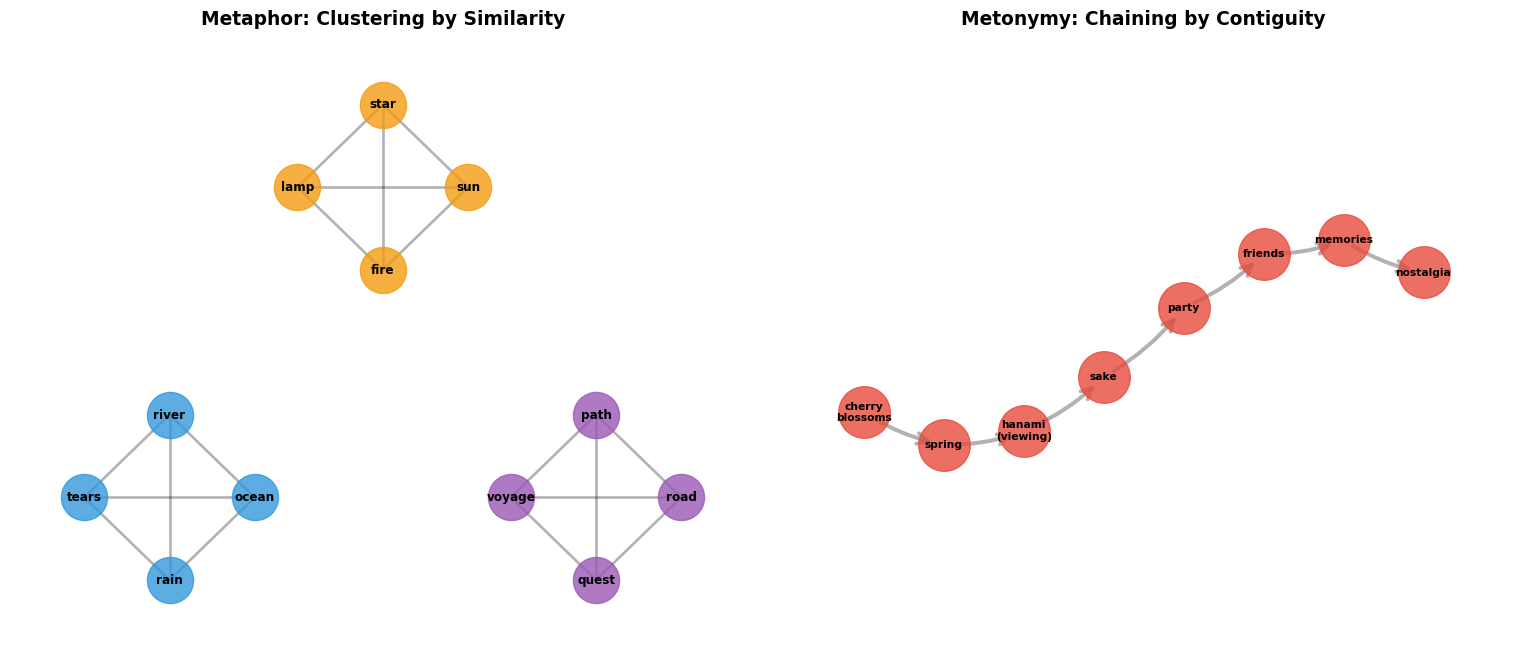

In [5]:
#| fig-cap: Metaphor groups by similarity, metonymy by co-occurrence. Different structures of meaning.
#| label: fig-metaphor-metonymy
#| code-fold: true

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Metaphor network (similarity clusters)
G_metaphor = nx.Graph()
clusters = {
    'Brightness': ['sun', 'star', 'lamp', 'fire'],
    'Water': ['ocean', 'river', 'tears', 'rain'],
    'Journey': ['road', 'path', 'voyage', 'quest']
}

for cluster, words in clusters.items():
    for word in words:
        G_metaphor.add_node(word, cluster=cluster)
    # Connect words within cluster
    for i, w1 in enumerate(words):
        for w2 in words[i+1:]:
            G_metaphor.add_edge(w1, w2)

# Position metaphor nodes in clusters
pos_metaphor = {}
cluster_centers = [(0, 2), (-2, -1), (2, -1)]
for (cluster, words), center in zip(clusters.items(), cluster_centers):
    angle_step = 2 * np.pi / len(words)
    for i, word in enumerate(words):
        angle = i * angle_step
        pos_metaphor[word] = (center[0] + 0.8 * np.cos(angle),
                             center[1] + 0.8 * np.sin(angle))

# Draw metaphor network
colors = {'Brightness': '#f39c12', 'Water': '#3498db', 'Journey': '#9b59b6'}
for cluster, words in clusters.items():
    nx.draw_networkx_nodes(G_metaphor, pos_metaphor, nodelist=words,
                          node_color=colors[cluster], node_size=1200,
                          alpha=0.8, ax=ax1)

nx.draw_networkx_edges(G_metaphor, pos_metaphor, alpha=0.3, width=2, ax=ax1)
nx.draw_networkx_labels(G_metaphor, pos_metaphor, font_size=9,
                       font_weight='bold', ax=ax1)

ax1.set_title('Metaphor: Clustering by Similarity', fontsize=14, fontweight='bold')
ax1.axis('off')
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-2.5, 3.5)

# Metonymy network (chain of associations)
G_metonymy = nx.DiGraph()
sequence = [
    ('cherry\nblossoms', 'spring'),
    ('spring', 'hanami\n(viewing)'),
    ('hanami\n(viewing)', 'sake'),
    ('sake', 'party'),
    ('party', 'friends'),
    ('friends', 'memories'),
    ('memories', 'nostalgia'),
]

for source, target in sequence:
    G_metonymy.add_edge(source, target)

# Position metonymy nodes in a flowing path
pos_metonymy = {}
x_positions = np.linspace(-3, 3, len(G_metonymy.nodes()))
y_positions = [0.5 * np.sin(x * 0.8) for x in x_positions]

for i, node in enumerate(G_metonymy.nodes()):
    pos_metonymy[node] = (x_positions[i], y_positions[i])

# Draw metonymy network
nx.draw_networkx_nodes(G_metonymy, pos_metonymy,
                      node_color='#e74c3c', node_size=1500,
                      alpha=0.8, ax=ax2)

nx.draw_networkx_edges(G_metonymy, pos_metonymy,
                      edge_color='gray', width=3, alpha=0.6,
                      arrowsize=20, arrowstyle='->', ax=ax2,
                      connectionstyle='arc3,rad=0.1')

nx.draw_networkx_labels(G_metonymy, pos_metonymy, font_size=8,
                       font_weight='bold', ax=ax2)

ax2.set_title('Metonymy: Chaining by Contiguity', fontsize=14, fontweight='bold')
ax2.axis('off')
ax2.set_xlim(-4, 4)
ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()